## Imports

In [ ]:
import os
import io
import zipfile
import urllib.request
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
import cv2
from sklearn.manifold import TSNE

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Device: {device}")

IMG_SIZE = 224
N_CLASSES = 5  # APTOS severity grades 0-4
BATCH_SIZE = 128
NUM_WORKERS = 4
APTOS_DIR = "data/aptos2019"

Device: cuda


## Dataset Preparation

In [90]:
# Dataset used download link - https://www.kaggle.com/datasets/mariaherrerot/aptos2019

train_csv = os.path.join(APTOS_DIR, "train.csv")
val_csv = os.path.join(APTOS_DIR, "val.csv")
test_csv = os.path.join(APTOS_DIR, "test.csv")

if os.path.exists(train_csv):
    df_train = pd.read_csv(train_csv)
    print(f"Loaded {len(df_train)} training labels from {train_csv}")
    print("Class distribution:", df_train['diagnosis'].value_counts().sort_index().to_dict())
else:
    raise FileNotFoundError(f"{train_csv} not found!")

if os.path.exists(val_csv):
    df_val = pd.read_csv(val_csv)
    print(f"Loaded {len(df_train)} training labels from {val_csv}")
    print("Class distribution:", df_val['diagnosis'].value_counts().sort_index().to_dict())
else:
    raise FileNotFoundError(f"{val_csv} not found!")

if os.path.exists(test_csv):
    df_test = pd.read_csv(test_csv)
    print(f"Loaded {len(df_test)} test labels from {test_csv}")
else:
    print(f"WARNING: {test_csv} not found!")
    df_test = pd.DataFrame(columns=['id_code'])

train_img_dir = os.path.join(APTOS_DIR, "train_images")
val_img_dir = os.path.join(APTOS_DIR, "val_images")
test_img_dir = os.path.join(APTOS_DIR, "test_images")
print(f"Train images dir exists: {os.path.exists(train_img_dir)}")
print(f"Val images dir exists: {os.path.exists(val_img_dir)}")
print(f"Test images dir exists: {os.path.exists(test_img_dir)}")

Loaded 2930 training labels from data/aptos2019\train.csv
Class distribution: {0: 1434, 1: 300, 2: 808, 3: 154, 4: 234}
Loaded 2930 training labels from data/aptos2019\val.csv
Class distribution: {0: 172, 1: 40, 2: 104, 3: 22, 4: 28}
Loaded 366 test labels from data/aptos2019\test.csv
Train images dir exists: True
Val images dir exists: True
Test images dir exists: True


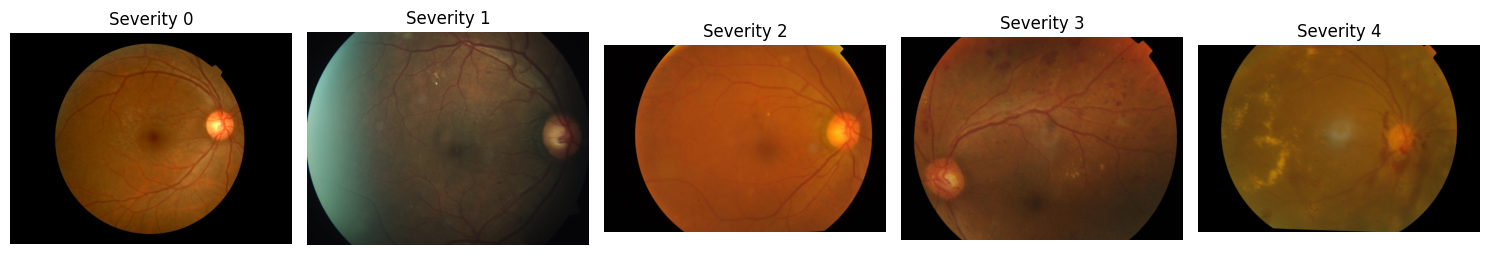

In [91]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for sev, ax in enumerate(axes):
    idx = df_train[df_train['diagnosis'] == sev].index[0]
    fname = df_train.loc[idx, 'id_code'] + ".png"
    fpath = os.path.join(train_img_dir, fname)
    img = Image.open(fpath).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Severity {sev}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [92]:
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['id_code'] + ".png"
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        label = row['diagnosis']

        if self.transform:
            image = self.transform(image)

        return image, label

In [93]:
# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = APTOSDataset(df_train, train_img_dir, transform=train_transform)
val_dataset = APTOSDataset(df_val, val_img_dir, transform=val_test_transform)
test_dataset = APTOSDataset(df_test, test_img_dir, transform=val_test_transform)

images, labels = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=True)))
print(f"Batch shape: {images.shape}, Labels shape: {labels.shape}")
print(f"Label range: {labels.min()} - {labels.max()}")

Batch shape: torch.Size([4, 3, 224, 224]), Labels shape: torch.Size([4])
Label range: 0 - 2


In [94]:
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

## Model Definition
We use MobileNetV2 as backbone with custom classifier head

In [95]:
def create_model(num_classes=N_CLASSES, pretrained=True, freeze_backbone=True):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1 if pretrained else None)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.2),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(512, num_classes)
    )

    return model

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model = create_model(freeze_backbone=True).to(device)
total_params, trainable_params = count_parameters(model)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")

print("\nModel architecture:")
print(model)

Total parameters: 2,882,309
Trainable parameters: 658,437
Frozen parameters: 2,223,872

Model architecture:
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
    

## Training Setup

In [96]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_score, model):
        if self.best_score is None:
            self.best_score = val_score
            self.best_model_state = model.state_dict().copy()
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.counter = 0
            self.best_model_state = model.state_dict().copy()

early_stopping = EarlyStopping(patience=7, min_delta=0.001)

In [97]:
# Training functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=True)

    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        current_acc = 100. * correct / total
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Validation', leave=True)

    with torch.no_grad():
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_acc = 100. * correct / total
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.2f}%'})

    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

# Test training step
print("Testing training step...")
train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)
print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

Testing training step...


Validation: 100%|██████████| 3/3 [01:00<00:00, 20.09s/it, loss=0.8192, acc=72.13%]

Train Loss: 1.1061, Train Acc: 60.34%
Val Loss: 0.8079, Val Acc: 72.13%


## Progressive Unfreezing Training

We'll train in stages:
1. Stage 1: Train only classifier head (backbone frozen)
2. Stage 2: Unfreeze last few layers of backbone
3. Stage 3: Unfreeze more layers with lower learning rate
4. Stage 4: Full fine-tuning with very low learning rate

In [100]:
def unfreeze_layers(model, num_layers_to_unfreeze):
    # MobileNetV2 features has 18 layers (0-17)
    features = list(model.features.children())
    total_layers = len(features)

    for param in model.features.parameters():
        param.requires_grad = False

    for i in range(max(0, total_layers - num_layers_to_unfreeze), total_layers):
        for param in features[i].parameters():
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Unfroze last {num_layers_to_unfreeze} layers. Trainable: {trainable:,} / {total:,}")


def train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, epochs, stage_name, early_stopping=None):

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in tqdm(range(epochs), desc=f"Stage: {stage_name}", unit="epoch"):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(val_acc)

        tqdm.write(f"Epoch {epoch+1}/{epochs} | "
                   f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                   f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}% | "
                   f"LR: {optimizer.param_groups[0]['lr']:.2e}")

        if early_stopping:
            early_stopping(val_acc, model)
            if early_stopping.early_stop:
                tqdm.write(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(early_stopping.best_model_state)
                break

    return history

In [ ]:
print("Stage 1: Training classifier head only...")
model = create_model(freeze_backbone=True).to(device)
total_params, trainable_params = count_parameters(model)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history1 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 1: Classifier Only",
                       early_stopping=early_stopping)


Stage 1: Training classifier head only...
Trainable parameters: 658,437 / 2,882,309


Stage: Stage 1: Classifier Only:   0%|          | 0/15 [00:00<?, ?epoch/s]

In [ ]:
print("Stage 2: Unfreezing last 4 layers...")
unfreeze_layers(model, 4)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history2 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 2: Last 4 Layers",
                       early_stopping=early_stopping)

In [ ]:
print("Stage 3: Unfreezing last 8 layers...")
unfreeze_layers(model, 8)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001)

history3 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=15, stage_name="Stage 3: Last 8 Layers",
                       early_stopping=early_stopping)

In [ ]:
print("Stage 4: Full fine-tuning...")
for param in model.parameters():
    param.requires_grad = True
total_params, trainable_params = count_parameters(model)
print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=10, min_delta=0.001)

history4 = train_stage(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       device, epochs=20, stage_name="Stage 4: Full Fine-tuning",
                       early_stopping=early_stopping)

In [1]:
full_history = {
    'train_loss': history1['train_loss'] + history2['train_loss'] + history3['train_loss'] + history4['train_loss'],
    'train_acc': history1['train_acc'] + history2['train_acc'] + history3['train_acc'] + history4['train_acc'],
    'val_loss': history1['val_loss'] + history2['val_loss'] + history3['val_loss'] + history4['val_loss'],
    'val_acc': history1['val_acc'] + history2['val_acc'] + history3['val_acc'] + history4['val_acc'],
}

# Save best model
torch.save(model.state_dict(), "mobilenetv2_aptos_best.pth")
print("\nBest model saved to mobilenetv2_aptos_best.pth")

NameError: name 'history1' is not defined

## Plotting

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

stage_boundaries = [
    len(history1['train_loss']),
    len(history1['train_loss']) + len(history2['train_loss']),
    len(history1['train_loss']) + len(history2['train_loss']) + len(history3['train_loss']),
]
stage_names = ['Stage 1', 'Stage 2', 'Stage 3', 'Stage 4']

axes[0, 0].plot(full_history['train_loss'], label='Train Loss')
axes[0, 0].plot(full_history['val_loss'], label='Val Loss')
for b in stage_boundaries:
    axes[0, 0].axvline(x=b, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training & Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(full_history['train_acc'], label='Train Acc')
axes[0, 1].plot(full_history['val_acc'], label='Val Acc')
for b in stage_boundaries:
    axes[0, 1].axvline(x=b, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training & Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

stage_val_accs = [
    max(history1['val_acc']),
    max(history2['val_acc']),
    max(history3['val_acc']),
    max(history4['val_acc']),
]
axes[1, 0].bar(stage_names, stage_val_accs, color=['skyblue', 'lightgreen', 'orange', 'salmon'])
axes[1, 0].set_ylabel('Best Val Accuracy (%)')
axes[1, 0].set_title('Best Validation Accuracy per Stage')
axes[1, 0].grid(True, alpha=0.3, axis='y')

lrs = []
for h in [history1, history2, history3, history4]:
    pass
axes[1, 1].text(0.5, 0.5, 'Learning Rate Schedule:\nStage 1: 1e-3\nStage 2: 5e-4\nStage 3: 1e-4\nStage 4: 5e-5',
                ha='center', va='center', fontsize=12, transform=axes[1, 1].transAxes)
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Model Evaluation

In [2]:
model.load_state_dict(torch.load("mobilenetv2_aptos_best.pth", map_location=device))
model.eval()

val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)
print(f"Final Validation Loss: {val_loss:.4f}")
print(f"Final Validation Accuracy: {val_acc:.2f}%")

class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=4))

cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

print("\nPer-class Accuracy:")
for i, name in enumerate(class_names):
    class_mask = np.array(val_labels) == i
    if class_mask.sum() > 0:
        class_acc = (np.array(val_preds)[class_mask] == i).mean() * 100
        print(f"  {name}: {class_acc:.2f}% ({class_mask.sum()} samples)")

NameError: name 'model' is not defined

## Feature Visualisation - Grad-CAM

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        output = self.model(x)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        target = output[0, class_idx]
        target.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = (weights[:, None, None] * activations).sum(dim=0)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

target_layer = model.features[-1][0]
gradcam = GradCAM(model, target_layer)

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return tensor * std + mean

val_images, val_labels = next(iter(val_loader))
val_images = val_images[:8].to(device)
val_labels = val_labels[:8]

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i in range(8):
    img = val_images[i:i+1]
    label = val_labels[i].item()

    orig_img = denormalize(img[0].cpu()).permute(1, 2, 0).numpy()
    orig_img = np.clip(orig_img, 0, 1)

    cam, pred_idx = gradcam(img)

    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

    overlay = 0.5 * orig_img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    axes[0, i].imshow(orig_img)
    axes[0, i].set_title(f"True: {class_names[label]}")
    axes[0, i].axis('off')

    axes[1, i].imshow(cam_resized, cmap='jet')
    axes[1, i].set_title(f"Grad-CAM")
    axes[1, i].axis('off')

    axes[2, i].imshow(overlay)
    axes[2, i].set_title(f"Overlay\nPred: {class_names[pred_idx]}")
    axes[2, i].axis('off')

    with torch.no_grad():
        features = model.features(img)
    feat_map = features[0, 0].cpu().numpy()
    axes[3, i].imshow(feat_map, cmap='viridis')
    axes[3, i].set_title(f"Feature Map (ch 0)")
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()

## Feature Map Visualisation

In [3]:
def get_feature_maps(model, x, layer_names):
    feature_maps = {}

    def hook_fn(name):
        def hook(module, input, output):
            feature_maps[name] = output.detach()
        return hook

    hooks = []
    for name in layer_names:
        layer = dict(model.named_modules())[name]
        hooks.append(layer.register_forward_hook(hook_fn(name)))

    with torch.no_grad():
        model(x)

    for h in hooks:
        h.remove()

    return feature_maps

layer_names = [
    'features.0',
    'features.3',
    'features.7',
    'features.14',
    'features.17',
]

sample_img, sample_label = val_dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

feature_maps = get_feature_maps(model, sample_img, layer_names)

fig, axes = plt.subplots(len(layer_names), 8, figsize=(20, 4*len(layer_names)))
for row_idx, layer_name in enumerate(layer_names):
    fmaps = feature_maps[layer_name][0]  # (C, H, W)
    n_channels = min(8, fmaps.shape[0])

    for ch in range(n_channels):
        fm = fmaps[ch].cpu().numpy()
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[row_idx, ch].imshow(fm, cmap='viridis')
        axes[row_idx, ch].set_title(f"{layer_name}\nCh {ch}")
        axes[row_idx, ch].axis('off')

    for ch in range(n_channels, 8):
        axes[row_idx, ch].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'val_dataset' is not defined

## t-SNE Visualisation of Learned Features

In [ ]:
def extract_features(model, loader, device):
    model.eval()
    features = []
    labels = []

    penultimate_features = []
    def hook(module, input, output):
        penultimate_features.append(output.detach())

    handle = model.classifier[1].register_forward_hook(hook)

    with torch.no_grad():
        for images, lbls in loader:
            images = images.to(device)
            _ = model(images)
            features.append(penultimate_features[-1].cpu())
            labels.append(lbls)
            penultimate_features.clear()

    handle.remove()
    return torch.cat(features), torch.cat(labels)

print("Extracting features for t-SNE...")
val_features, val_labels_tsne = extract_features(model, val_loader, device)
print(f"Features shape: {val_features.shape}")

print("Running t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
features_2d = tsne.fit_transform(val_features.numpy())

plt.figure(figsize=(10, 8))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=val_labels_tsne.numpy(),
                      cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Severity Grade')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE Visualization of Penultimate Layer Features (Validation Set)')
plt.grid(True, alpha=0.3)
plt.show()